In [1]:
from pathlib import Path

import numpy as np
import dask.distributed as dd
import scanpy as sc
import anndata as ad
import h5py
import time

import warnings
warnings.filterwarnings("ignore")

sc.logging.print_header()

Package,Version
dask,2026.1.2 (2025.12.0)
h5py,3.15.1
Component,Info
Python,"3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]"
OS,Linux-4.18.0-425.3.1.el8.x86_64-x86_64-with-glibc2.28
CPU,"64 logical CPU cores, x86_64"
GPU,"ID: 0, NVIDIA A100-PCIE-40GB, Driver: 560.35.03, Memory: 40960 MiB"
Updated,2026-02-24 11:35
Dependency,Version
sparse,0.17.0


In [2]:
# conda activate dvc-cellflow
# dask-scheduler
# srun --nodes=2 --ntasks=2 dask-worker tcp://192.168.203.9:8786

In [2]:
# cluster = dd.LocalCluster()
# client = dd.Client(cluster)
client = dd.Client("tcp://192.168.203.9:8786")

In [3]:
client

<Client: 'tcp://192.168.203.9:8786' processes=2 threads=32, memory=250.94 GiB>

In [8]:
CHUNK_SIZE = 100_000

In [9]:
with h5py.File("raw/Parse_10M_PBMC_cytokines.h5ad", "r") as f:
    adata = ad.AnnData(
        obs=ad.experimental.read_elem(f["obs"]),
        var=ad.experimental.read_elem(f["var"]),
    )
    adata.X = ad.experimental.read_elem_as_dask(
        f["X"], chunks=[CHUNK_SIZE, adata.shape[1]]
    )

In [10]:
#adata.layers["counts"] = adata.X.copy()  # Making sure we keep access to the raw counts

In [ ]:
# sc.pp.highly_variable_genes(adata, 
#                             n_top_genes=2000, 
#                             flavor="seurat_v3",
#                             batch_key="donor")

In [16]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

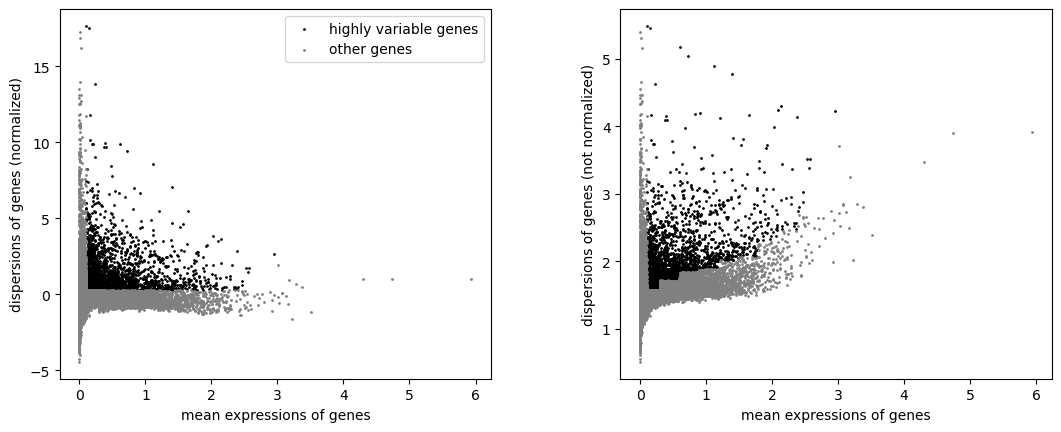

In [22]:
sc.pp.highly_variable_genes(adata, min_mean=0.1, max_mean=3, min_disp=0.3)
sc.pl.highly_variable_genes(adata) 

In [ ]:
#adata = adata[:, adata.var['highly_variable']]

In [23]:
adata.var['highly_variable'].value_counts()

highly_variable
False    37616
True      2736
Name: count, dtype: int64

In [ ]:
del adata.layers['counts']

In [ ]:
control_key = "is_control"
condition_keys = "cytokine"
condition_rep_keys = "condition_embeddings"

In [ ]:
adata.obs[control_key] = (adata.obs[condition_keys] == "PBS")
condition_list = adata[adata.obs[control_key]==False].obs[condition_keys].unique()

In [ ]:
random_seed = 42
rng = np.random.default_rng(random_seed) 
test_ratio = 0.2
condition_list = list(condition_list)
zero_shot = True
n_test = max(1, int(len(condition_list) * test_ratio))
test_condition = rng.choice(condition_list, size=n_test, replace=False).tolist()
print(test_condition)
train_condition = [g for g in condition_list if g not in test_condition]

In [ ]:
adata_pca = adata[~adata.obs[condition_keys].isin(test_condition)]

In [ ]:
adata_pca = adata_pca.to_memory(copy=False)

In [ ]:
use_hv = True
adata_pca.uns['pca'] = {}
adata_pca.uns['pca']['params'] = {
    'zero_center': True,
    'use_highly_variable': use_hv,
}

adata_pca.var['mean'] = adata_pca.X.mean(0).A1
adata_pca.var['std'] = sparse_std(adata_pca.X)

S = lanczos(adata_pca.X,100,center=adata_pca.var['mean'],scale=adata_pca.var['std'])

adata_pca.obsm['X_pca'] = (S.U * S.s)
adata_pca.varm['PCs'] = S.V
adata_pca.uns['pca']['variance'] = adata_pca.obsm['X_pca'].var(0)
adata_pca.uns['pca']['variance_ratio'] = adata_pca.uns['pca']['variance'] / (adata_pca.X.shape[1] - 1 )
adata_pca.varm["X_mean"] = np.array(adata_pca.var['mean'])

In [ ]:
adata_pca.obsm["X_pca"]

In [ ]:
adata_pca.write_h5ad("raw/PBMC_pca_rep_0.2_42.h5ad")

In [13]:
def sparse_std(X,blocksize=100):
    """
    Return the std deviation of the columns of a sparse matrix.
    
    inputs
        X: sparse matrix

        blocksize: number of columns to calculate in parallel. Larger
        blocksize will increase memory usage as this function converts 
        each block to a dense matrix and uses the numpy .std() function
    
    outputs
        X_std: numpy vector with std deviation of each column of X
    
    """
    n,m = X.shape
    blocksize = 100
    k = int(m/blocksize)
    X_std = []
    for i in range(k):
        X_std += list(X[:,blocksize*i:blocksize*(i+1)].todense().std(0).A1)
    X_std += list(X[:,k*blocksize:].todense().std(0).A1)
    X_std = np.array(X_std)
    return X_std

In [14]:
#   irlbpy code
#       From:   https://github.com/airysen/irlbpy
#       Date:   2021-12
#       License: Apache License, V 2.0, January 2004
#
#       Code unmodified except:
#           Added two print (feedback) blocks
#           Ran through lint formatting tool 'black' https://github.com/psf/black
#
import numpy as np
import scipy.sparse as sparse
import warnings

from numpy.fft import rfft, irfft
import numpy.linalg as nla


# Matrix-vector product wrapper
# A is a numpy 2d array or matrix, or a scipy matrix or sparse matrix.
# x is a numpy vector only.
# Compute A.dot(x) if t is False,  A.transpose().dot(x)  otherwise.


def multA(A, x, TP=False, L=None):
    if sparse.issparse(A):
        # m = A.shape[0]
        # n = A.shape[1]
        if TP:
            return sparse.csr_matrix(x).dot(A).transpose().todense().A[:, 0]
        return A.dot(sparse.csr_matrix(x).transpose()).todense().A[:, 0]
    if TP:
        return x.dot(A)
    return A.dot(x)


def multS(s, v, L, TP=False):
    N = s.shape[0]
    vp = prepare_v(v, N, L, TP=TP)
    p = irfft(rfft(vp) * rfft(s))
    if not TP:
        return p[:L]
    return p[L - 1 :]


def prepare_s(s, L=None):
    N = s.shape[0]
    if L is None:
        L = N // 2
    K = N - L + 1
    return np.roll(s, K - 1)


def prepare_v(v, N, L, TP=False):
    v = v.flatten()[::-1]
    K = N - L + 1
    if TP:
        lencheck = L
        if v.shape[0] != lencheck:
            raise VectorLengthException(
                "Length of v must be  L (if transpose flag is True)"
            )
        pw = K - 1
        v = np.pad(v, (pw, 0), mode="constant", constant_values=0)
    elif not TP:
        lencheck = N - L + 1
        if v.shape[0] != lencheck:
            raise VectorLengthException("Length of v must be N-K+1")
        pw = L - 1
        v = np.pad(v, (0, pw), mode="constant", constant_values=0)
    return v


def orthog(Y, X):
    """Orthogonalize a vector or matrix Y against the columns of the matrix X.
    This function requires that the column dimension of Y is less than X and
    that Y and X have the same number of rows.
    """
    dotY = multA(X, Y, TP=True)
    return Y - multA(X, dotY)


# Simple utility function used to check linear dependencies during computation:


def invcheck(x):
    # eps2 = 2 * np.finfo(np.float).eps
    eps2 = 2 * np.finfo(float).eps
    if x > eps2:
        x = 1 / x
    else:
        x = 0
        warnings.warn("Ill-conditioning encountered, result accuracy may be poor")
    return x


def lanczos(A, nval, tol=0.0001, maxit=50, center=None, scale=None, L=None):
    """Estimate a few of the largest singular values and corresponding singular
    vectors of matrix using the implicitly restarted Lanczos bidiagonalization
    method of Baglama and Reichel, see:

    Augmented Implicitly Restarted Lanczos Bidiagonalization Methods,
    J. Baglama and L. Reichel, SIAM J. Sci. Comput. 2005

    Keyword arguments:
    tol   -- An estimation tolerance. Smaller means more accurate estimates.
    maxit -- Maximum number of Lanczos iterations allowed.

    Given an input matrix A of dimension j * k, and an input desired number
    of singular values n, the function returns a tuple X with five entries:

    X[0] A j * nu matrix of estimated left singular vectors.
    X[1] A vector of length nu of estimated singular values.
    X[2] A k * nu matrix of estimated right singular vectors.
    X[3] The number of Lanczos iterations run.
    X[4] The number of matrix-vector products run.

    The algorithm estimates the truncated singular value decomposition:
    A.dot(X[2]) = X[0]*X[1].
    """

    import sys

    print(
        f">> lanczos A={A.shape}, nval={nval}, tol={tol}, maxit={maxit}",
        file=sys.stdout,
    )
    center_story = "None" if center is None else f"{center.shape}"
    scale_story = "None" if scale is None else f"{scale.shape}"
    print(f"++ lanczos center={center_story}, scale={scale_story}", file=sys.stdout)
    sys.stdout.flush()

    mmult = None
    m = None
    n = None
    if A.ndim == 2:
        mmult = multA
        m = A.shape[0]
        n = A.shape[1]
        if min(m, n) < 2:
            raise MatrixShapeException("The input matrix must be at least 2x2.")

    elif A.ndim == 1:
        mmult = multS
        A = np.pad(A, (0, A.shape[0] % 2), mode="edge")
        N = A.shape[0]
        if L is None:
            L = N // 2
        K = N - L + 1
        m = L
        n = K
        A = prepare_s(A, L)
    elif A.ndim > 2:
        raise MatrixShapeException("The input matrix must be 2D array")
    nu = nval

    m_b = min((nu + 20, 3 * nu, n))  # Working dimension size
    mprod = 0
    it = 0
    j = 0
    k = nu
    smax = 1
    # sparse = sparse.issparse(A)

    V = np.zeros((n, m_b))
    W = np.zeros((m, m_b))
    F = np.zeros((n, 1))
    B = np.zeros((m_b, m_b))

    V[:, 0] = np.random.randn(n)  # Initial vector
    V[:, 0] = V[:, 0] / np.linalg.norm(V)

    while it < maxit:
        if it > 0:
            j = k

        VJ = V[:, j]

        # apply scaling
        if scale is not None:
            VJ = VJ / scale

        W[:, j] = mmult(A, VJ, L=L)
        mprod = mprod + 1

        # apply centering
        # R code: W[, j_w] <- W[, j_w] - ds * drop(cross(dv, VJ)) * du
        if center is not None:
            W[:, j] = W[:, j] - np.dot(center, VJ)

        if it > 0:
            # NB W[:,0:j] selects columns 0,1,...,j-1
            W[:, j] = orthog(W[:, j], W[:, 0:j])
        s = np.linalg.norm(W[:, j])
        sinv = invcheck(s)
        W[:, j] = sinv * W[:, j]

        # Lanczos process
        while j < m_b:
            F = mmult(A, W[:, j], TP=True, L=L)
            mprod = mprod + 1

            # apply scaling
            if scale is not None:
                F = F / scale

            F = F - s * V[:, j]
            F = orthog(F, V[:, 0 : j + 1])
            fn = np.linalg.norm(F)
            fninv = invcheck(fn)
            F = fninv * F
            if j < m_b - 1:
                V[:, j + 1] = F
                B[j, j] = s
                B[j, j + 1] = fn
                VJp1 = V[:, j + 1]

                # apply scaling
                if scale is not None:
                    VJp1 = VJp1 / scale

                W[:, j + 1] = mmult(A, VJp1, L=L)
                mprod = mprod + 1

                # apply centering
                # R code: W[, jp1_w] <- W[, jp1_w] - ds * drop(cross(dv, VJP1))
                # * du
                if center is not None:
                    W[:, j + 1] = W[:, j + 1] - np.dot(center, VJp1)

                # One step of classical Gram-Schmidt...
                W[:, j + 1] = W[:, j + 1] - fn * W[:, j]
                # ...with full reorthogonalization
                W[:, j + 1] = orthog(W[:, j + 1], W[:, 0 : (j + 1)])
                s = np.linalg.norm(W[:, j + 1])
                sinv = invcheck(s)
                W[:, j + 1] = sinv * W[:, j + 1]
            else:
                B[j, j] = s
            j = j + 1
        # End of Lanczos process
        S = nla.svd(B)
        R = fn * S[0][m_b - 1, :]  # Residuals
        if it == 0:
            smax = S[1][0]  # Largest Ritz value
        else:
            smax = max((S[1][0], smax))

        conv = sum(np.abs(R[0:nu]) < tol * smax)
        if conv < nu:  # Not coverged yet
            k = max(conv + nu, k)
            k = min(k, m_b - 3)
        else:
            break
        # Update the Ritz vectors
        V[:, 0:k] = V[:, 0:m_b].dot(S[2].transpose()[:, 0:k])
        V[:, k] = F
        B = np.zeros((m_b, m_b))
        # Improve this! There must be better way to assign diagonal...
        for l in range(k):
            B[l, l] = S[1][l]
        B[0:k, k] = R[0:k]
        # Update the left approximate singular vectors
        W[:, 0:k] = W[:, 0:m_b].dot(S[0][:, 0:k])
        it = it + 1

    U = W[:, 0:m_b].dot(S[0][:, 0:nu])
    V = V[:, 0:m_b].dot(S[2].transpose()[:, 0:nu])
    # return((U, S[1][0:nu], V, it, mprod))

    print(f"<< lanczos it={it} mprod={mprod}", file=sys.stdout)
    sys.stdout.flush()

    return LanczosResult(
        **{"U": U, "s": S[1][0:nu], "V": V, "steps": it, "nmult": mprod}
    )


class LanczosResult:
    def __init__(self, **kwargs):
        for key in kwargs:
            setattr(self, key, kwargs[key])


class VectorLengthException(Exception):
    pass


class MatrixShapeException(Exception):
    pass

In [ ]:
adata.write_h5ad("raw/PBMC_hvg.h5ad")

In [17]:
adata.obs["donor"].value_counts()

donor
Donor1     1267690
Donor5     1066725
Donor12    1054708
Donor6      974030
Donor2      931569
Donor3      695158
Donor7      652386
Donor8      650974
Donor9      632341
Donor11     613365
Donor10     580786
Donor4      578242
Name: count, dtype: int64

In [30]:
adata[adata.obs["donor"]=="Donor6"].obs["cytokine"].value_counts()

cytokine
PBS            59158
IL-9           21433
IL-1Ra         17947
IL-36-alpha    17476
IL-7           16209
               ...  
IFN-gamma       6497
IL-17D          6387
IL-4            6088
C5a             5844
GM-CSF          5389
Name: count, Length: 91, dtype: int64

In [12]:
donor_rep_keys = "donor_one_hot"

In [13]:
for i in range(12):
    adata_mem = adata[adata.obs["donor"]==f"Donor{i+1}"].to_memory(copy=False)
    adata_mem.obs[donor_rep_keys] = i+1
    adata_mem.write_h5ad(f"raw/PBMC_donor{i+1}_hvg_2000.h5ad")
    print(adata_mem)

AnnData object with n_obs × n_vars = 1267690 × 5412
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'donor_one_hot'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'
AnnData object with n_obs × n_vars = 931569 × 5412
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'donor_one_hot'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'
AnnData

In [14]:
adata

View of AnnData object with n_obs × n_vars = 9697974 × 5412
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'

In [2]:
adata = sc.read_h5ad("raw/Parse_10M_PBMC_cytokines.h5ad",backed = 'r')

In [11]:
adata.obs["cytokine"].value_counts()

cytokine
PBS            629701
CT-1           136899
IL-36-alpha    135264
IL-9           130692
TSLP           129206
                ...  
IL-11           82049
IL-17B          81210
BAFF            77408
IFN-omega       77129
APRIL           72563
Name: count, Length: 91, dtype: int64

In [15]:
import pandas as pd
vc = adata[adata.obs["cytokine"] != "PBS"].obs["cytokine"].value_counts().index

pd.DataFrame({"cytokine": vc}).to_csv(
    "target_cytokine_PBMC.csv",
    index=False
)

In [16]:
print(vc)

CategoricalIndex(['CT-1', 'IL-36-alpha', 'IL-9', 'TSLP', 'IL-7', 'IL-36Ra',
                  'IL-33', 'IL-13', 'G-CSF', 'IL-23', 'IL-21', 'SCF', 'OSM',
                  'IFN-alpha1', 'IL-15', 'LIGHT', 'CD27L', 'IL-4', 'IL-34',
                  'IL-17F', '4-1BBL', 'IFN-epsilon', 'ADSF', 'Noggin', 'IL-31',
                  'TRAIL', 'IL-1Ra', 'IL-12', 'LIF', 'TNF-alpha', 'IL-20',
                  'IL-10', 'IL-1-beta', 'EGF', 'IL-18Ra', 'FasL', 'CD30L',
                  'IL-27', 'IFN-lambda1', 'Leptin', 'IL-22', 'IL-17D',
                  'Decorin', 'RANKL', 'IL-32-beta', 'GM-CSF', 'IL-19', 'IL-2',
                  'IFN-lambda2', 'IFN-gamma', 'IL-17E', 'IL-1-alpha', 'IL-6',
                  'FLT3L', 'IL-35', 'IGF-1', 'IFN-beta', 'TWEAK', 'IL-3',
                  'TPO', 'EPO', 'IL-5', 'OX40L', 'PSPN', 'LAP-TGF-beta1',
                  'IL-8', 'LT-alpha1-beta2', 'FGF-beta', 'IL-16', 'HGF',
                  'IL-17A', 'PRL', 'IL-17C', 'GDNF', 'IL-26', 'GITRL', 'CD40L',
            

In [17]:
adata.var

,n_cells
TSPAN6,15700
TNMD,585
DPM1,1984849
SCYL3,2042340
C1orf112,1378182
...,...
POLGARF,73910
LY6S,3613
ENSG00000291313,1372
ENSG00000291316,23362
